# Essai de coder un algorithme de Grover avec une augmentation d'amplitude

D'après l'article, il faudrait coder dans cet ordre : 

* Step 1: Determine the number of iterations (k) using the given initial success probability (p), as per Eqn. 4.
* Step 2: If k is a natural number, set k′ = k and proceed directly to Step 8.
* Step 3: (If k is not a natural number) : Calculate the number of iterations, k′, based on the value of k,using Eqn. 9.
* Step 4: Compute the new required initial success probability (p′) using Eqn. 11.
* Step 5: Find the angle of rotation (ϕ) for the Ry operator from Eqn. 12.
* Step 6: Introduce an auxiliary qubit into the existing Grover’s or amplitude amplification algorithm and initialize it with Ry(ϕ) gate using the angle ϕ.
* Step 7: Modify the existing oracle by adding a control from the auxiliary qubit, ensuring that it marks target states only when the auxiliary qubit is in state |0⟩ (as per Eqn. 7).
* Step 8: Apply the oracle to mark the target states.
* Step 9: Apply the diffusion operator to increase the amplitude of the marked states.
* Step 10: Repeat Step 8 and Step 9, k′ times.
* Step 11: Measure the final state to obtain one of the target states with certainty.

**L'algorithme devrait ressembler à ça :**
![Algo sur lequel je vais me baser](img/deterministric_algorithm.png)


In [110]:
# Built-in modules
import math
import numpy as np

# Imports from Qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## Paramètres initiaux 

### Variables choisies 

In [111]:
marked_states = ["111011"]
n = len(marked_states[0])
M = len(marked_states)
N = 2**n

### Variables calculées

In [112]:


def parametres(M, N):
    """
    Calcule les paramètres k' et phi selon le framework algorithmique
    décrit dans la Section 4 du document.
    """
    # 1. Probabilité de succès initiale (Eqn 2)
    p = M / N 
    
    # 2. Calcul du nombre d'itérations théorique k (Eqn 4)
    # k = (pi / (4 * arcsin(sqrt(p)))) - 1/2
    k = (np.pi / (4 * np.arcsin(np.sqrt(p)))) - 0.5 
    
    # 3. Choix de k' : on prend toujours l'entier supérieur (Eqn 9)
    # Cela garantit qu'on a assez de rotation pour atteindre la cible
    k_prime = int(np.ceil(k)) 
    
    # 4. Calcul de la nouvelle probabilité cible p' (Eqn 11)
    # C'est la probabilité idéale pour que k_prime soit l'optimum parfait
    p_prime = np.sin(np.pi / (4 * (k_prime + 0.5)))**2 

    # 5. Calcul de l'angle phi pour le qubit auxiliaire (Eqn 12)
    # phi = 2 * arccos(sqrt(p_prime / p))
    # Cet angle va "réduire" p vers p' au début du circuit
    phi = 2 * np.arccos(np.sqrt(p_prime / p)) 
    
    return k_prime, phi

k,phi = parametres(M, N)


### Création du circuit 


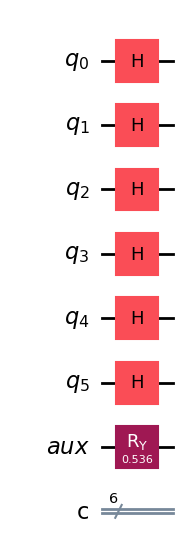

In [113]:
# On crée un registre de 4 qubits pour la recherche (nommés 'q')
q_reg = QuantumRegister(n, 'q')

# On crée un registre de 1 qubit pour l'auxiliaire (nommé 'aux')
aux_reg = QuantumRegister(1, 'aux')

# On crée un registre classique pour les résultats
c_reg = ClassicalRegister(n, 'c')

# On crée le circuit avec ces registres
circ = QuantumCircuit(q_reg, aux_reg, c_reg)

circ.h(range(n))
circ.ry(phi,aux_reg[0])
circ.draw(output="mpl", style="iqp")

## Grover

In [114]:
def oracle(marked_states):
    """
    Construit l'oracle de Grover pour un ou plusieurs états marqués.
    
    Parameters:
        marked_states (str or list): États cibles
    
    Returns:
        QuantumCircuit: Circuit oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    
    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits)
    
    for target in marked_states:
        rev_target = target[::-1]
        zero_inds = [
            ind for ind in range(num_qubits) if rev_target.startswith("0", ind)
        ]
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)
    
    return qc

def oracle_prepare(marked_states):
    # On réutilise ta fonction oracle() mais on la transforme en porte contrôlée
    gate_oracle = oracle(marked_states).to_gate()
    
    # On crée un contrôle sur l'état |0> (ctrl_state='0')
    # Cela signifie que l'oracle s'active seulement si l'auxiliaire est à 0
    controlled_gate = gate_oracle.control(1, ctrl_state='0')
    return controlled_gate

def diffusion(num_qubits):
    """
    Construit l'opérateur de diffusion (réflexion autour de la moyenne).
    
    Parameters:
        num_qubits (int): Nombre de qubits
    
    Returns:
        QuantumCircuit: Circuit de diffusion
    """
    qc = QuantumCircuit(num_qubits)
    
    qc.h(range(num_qubits))
    qc.x(range(num_qubits))
    qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    qc.x(range(num_qubits))
    qc.h(range(num_qubits))
    
    return qc


def grover(marked_states):
    """
    Construit et exécute le circuit de Grover complet.
    
    Parameters:
        marked_states (str or list): États cibles
    
    Returns:
        QuantumCircuit: Circuit de Grover complet avec mesures
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    
    num_qubits = len(marked_states[0])
    N = 2 ** num_qubits
    M = len(marked_states)
    
    # Nombre optimal d'itérations
    k = math.floor(
        math.pi / (4 * math.asin(math.sqrt(M / N)))
    )
    
    # Construction du circuit
    qc = QuantumCircuit(num_qubits)
    
    # Superposition initiale uniforme
    qc.h(range(num_qubits))
    
    # k itérations oracle + diffusion
    for _ in range(k):
        qc.compose(oracle(marked_states), inplace=True)
        qc.compose(diffusion(num_qubits), inplace=True)
    
    qc.measure_all()
    
    return qc

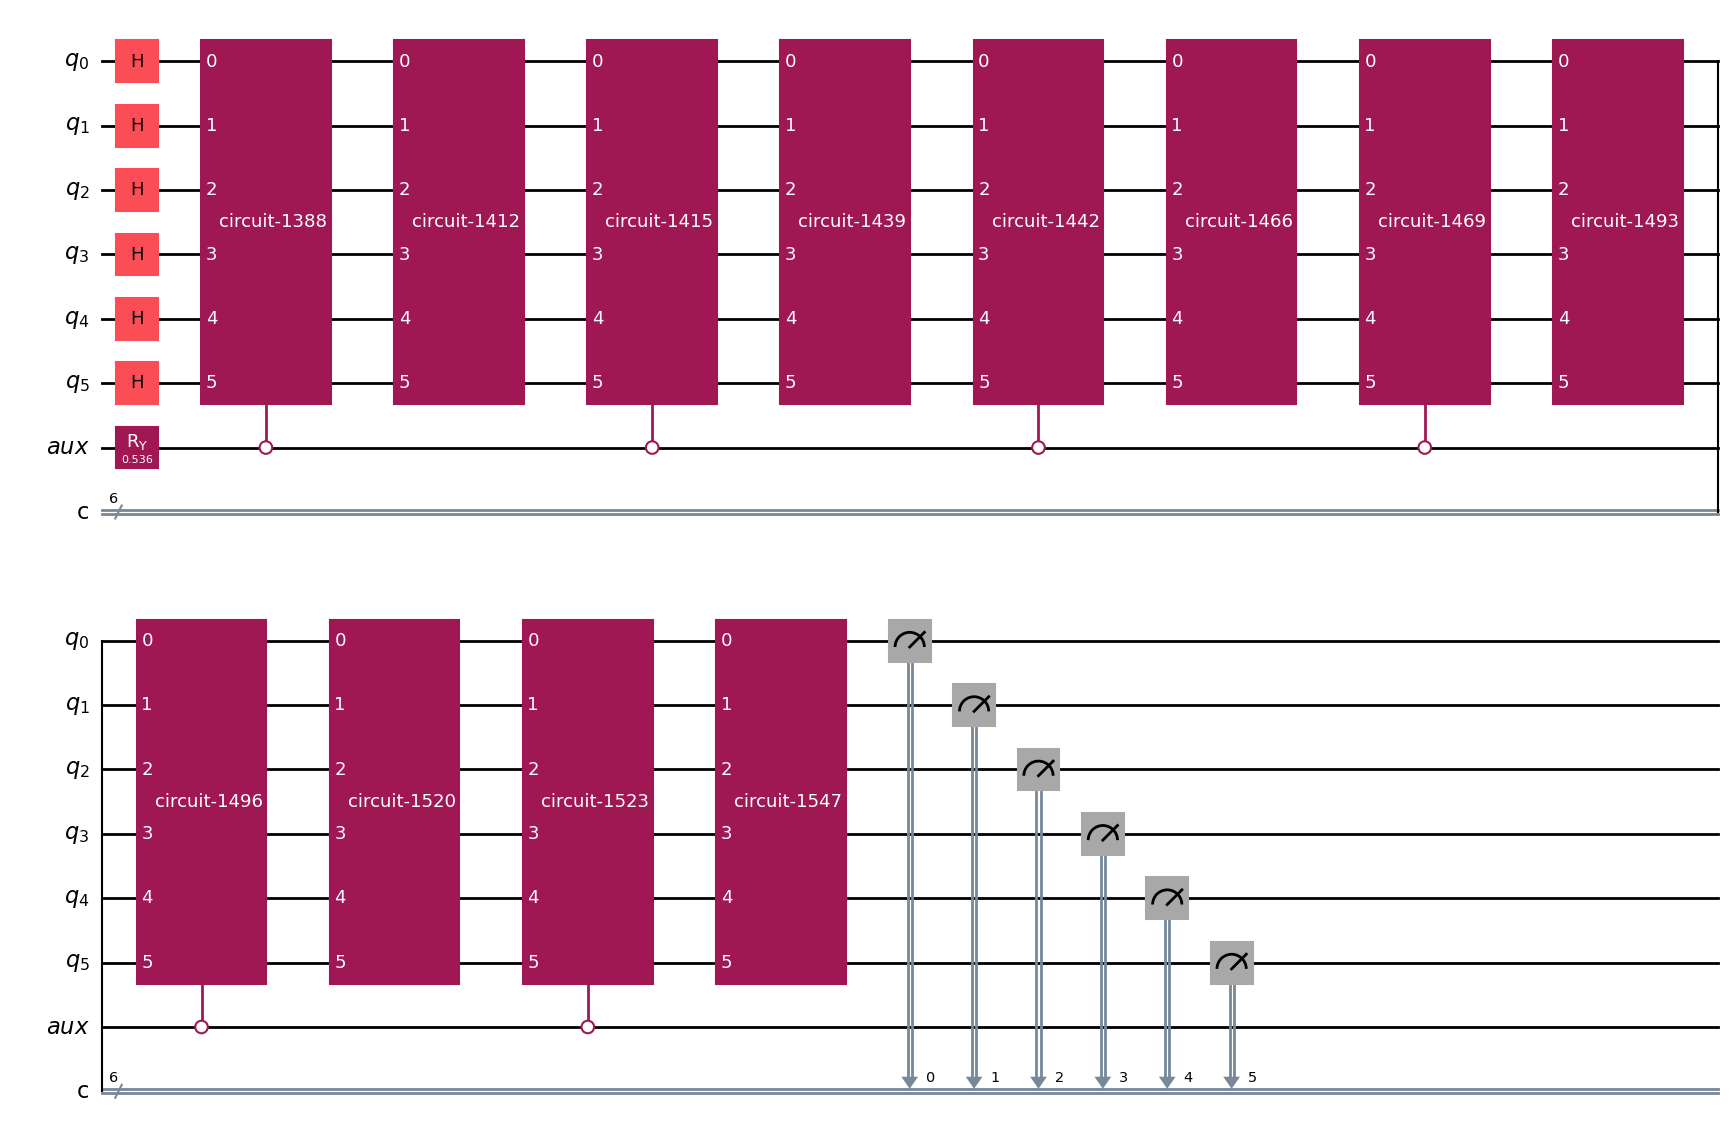

In [115]:
oracle_test = grover(marked_states) # Utilisez un nom différent
oracle_test.draw(output="mpl", style="iqp")

iterations, phi = parametres(M, N)

# Initialisation du circuit avec tes registres q_reg et aux_reg
qc_final = QuantumCircuit(q_reg, aux_reg, c_reg)

# --- INITIALISATION ---
qc_final.h(q_reg)             # Superposition uniforme sur les qubits de recherche
qc_final.ry(phi, aux_reg[0])  # ÉTAPE 6 : Rotation Ry(phi) sur l'auxiliaire

# --- BOUCLE DE GROVER (k' fois) ---
# ÉTAPE 10 : On répète k' fois
for _ in range(iterations):
    # ÉTAPE 8 : Oracle contrôlé
    # Le qubit aux_reg[0] contrôle les qubits de q_reg
    oracle_gate = oracle_prepare(marked_states)
    to_add = [q_reg[i] for i in range(0,n)]
    qc_final.append(oracle_gate, [aux_reg[0]] + to_add)
    
    # ÉTAPE 9 : Diffuseur (uniquement sur les qubits de recherche)
    # On réutilise ta fonction diffusion()
    diff_gate = diffusion(n).to_gate()
    qc_final.append(diff_gate, q_reg)

# --- MESURE (Étape 11) ---
qc_final.measure(q_reg, c_reg)

qc_final.draw(output="mpl", style="iqp")

Résultats : {'100101': 1, '111011': 967, '010001': 1, '011010': 2, '010010': 3, '101100': 2, '111010': 6, '001111': 1, '010101': 5, '000100': 2, '110011': 1, '010111': 1, '001101': 1, '100100': 1, '111100': 3, '110111': 2, '100011': 2, '001100': 1, '101011': 1, '000010': 1, '100010': 1, '111110': 2, '000001': 1, '101010': 1, '101000': 2, '011011': 1, '011111': 1, '010011': 1, '010000': 1, '000111': 1, '110000': 1, '101001': 1, '000101': 1, '100000': 1, '001010': 1, '011110': 1, '000110': 1, '101111': 1}


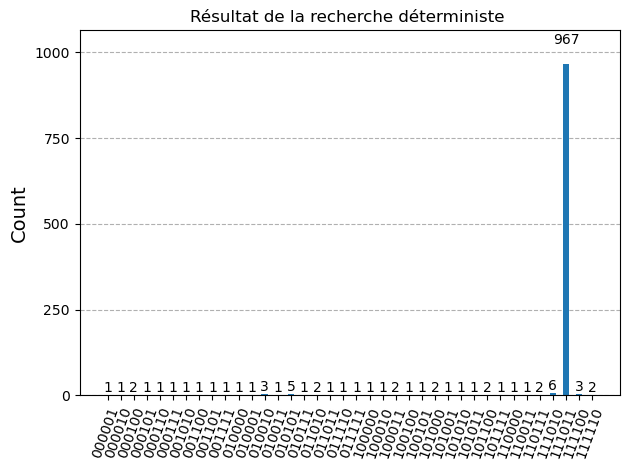

In [116]:
simulator = AerSimulator()

# On décompose pour que le simulateur comprenne les portes complexes
qc_compiled = qc_final.decompose().decompose()
job = simulator.run(qc_compiled, shots=1024)
result = job.result()
counts = result.get_counts()

print("Résultats :", counts)
plot_histogram(counts, title="Résultat de la recherche déterministe ")


**ok en fait le but de l'algo c'est de partir d'une répartition uniforme, et on va faire une rotation ry(\phi) avec le qbit de base pour que ça soit non uniforme et optimisé**